# Data Reading and Initial Setup

In [96]:
import json
import re
import codecs
from datetime import datetime, timezone
from collections import Counter

import nltk
from nltk.corpus import stopwords
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from langdetect import detect, LangDetectException

from resources.abbreviations import ABBREVIATIONS

POS_WORDS_FILE = "resources/positive-words.txt"
NEG_WORDS_FILE = "resources/negative-words.txt"

abbrev_pattern = re.compile(
    r'\b(' + '|'.join(re.escape(k) for k in ABBREVIATIONS.keys()) + r')\b'
)
stop_words = set(stopwords.words('english'))


def load_words(pos_path=POS_WORDS_FILE, neg_path=NEG_WORDS_FILE):
    with open(pos_path, 'r', encoding='utf-8', errors='ignore') as f:
        pos = set(line.strip() for line in f if line.strip() and not line.startswith(';'))
    with codecs.open(neg_path, 'r', encoding='utf-8', errors='ignore') as f:
        neg = set(line.strip() for line in f if line.strip() and not line.startswith(';'))
    return pos, neg


def load_comments(filepath):
    """Load English comments from a YouTube JSON file."""
    comments = []
    skipped_non_english = 0
    skipped_empty = 0

    with open(filepath) as f:
        data = json.load(f)

    for video in data["videos"]:
        for comment in video.get("comments", []):
            text = comment.get("text", "").strip()
            if not text:
                skipped_empty += 1
                continue
            try:
                if detect(text) != 'en':
                    skipped_non_english += 1
                    continue
            except LangDetectException:
                skipped_non_english += 1
                continue

            comments.append({
                "author": comment["author"],
                "raw_text": text,
                "text": text.lower(),
                "publishedAt": comment["publishedAt"],
                "likeCount": comment["likeCount"],
                "videoTitle": video["title"],
                "channelTitle": video.get("channelTitle", ""),
            })

    print(f"{filepath}: {len(comments)} kept, {skipped_non_english} non-English, {skipped_empty} empty")
    return comments

legacy_comments = load_comments("dataCollection/data/legacy.json")
modern_comments = load_comments("dataCollection/data/modern.json")

dataCollection/data/legacy.json: 14550 kept, 2192 non-English, 2 empty
dataCollection/data/modern.json: 12509 kept, 1711 non-English, 0 empty


## Number of Unique Commenters

In [97]:
def commenter_stats(comments, label):
    authors = [c["author"] for c in comments]
    total = len(authors)
    unique = len(set(authors))
    print(f"{label}")
    print(f"  Total comments:    {total}")
    print(f"  Unique commenters: {unique}")
    return set(authors)

legacy_authors  = commenter_stats(legacy_comments,  "Legacy")
modern_authors  = commenter_stats(modern_comments,  "Modern")

all_comments = legacy_comments + modern_comments
all_authors  = legacy_authors | modern_authors
total        = len(all_comments)
unique       = len(all_authors)
print(f"Combined")
print(f"  Total comments:    {total}")
print(f"  Unique commenters: {unique}")
print(f"  Overlap (on both): {len(legacy_authors & modern_authors)}")

Legacy
  Total comments:    14550
  Unique commenters: 13200
Modern
  Total comments:    12509
  Unique commenters: 11550
Combined
  Total comments:    27059
  Unique commenters: 24350
  Overlap (on both): 400


## Timeline of comments

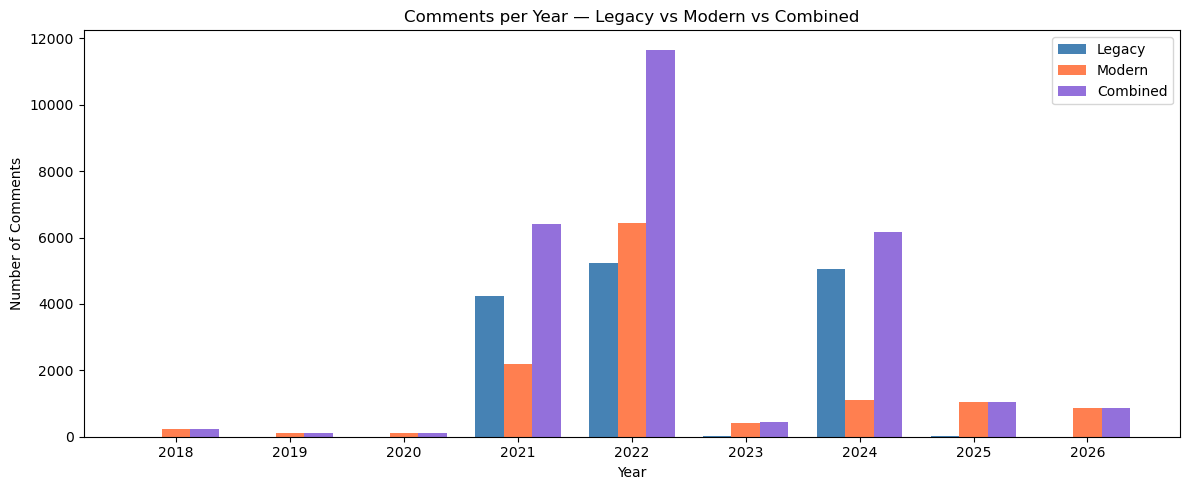

In [98]:
from collections import defaultdict

def comments_by_year(comments):
    counts = defaultdict(int)
    for c in comments:
        year = datetime.fromisoformat(c["publishedAt"].replace("Z", "+00:00")).year
        counts[year] += 1
    return counts

legacy_by_year  = comments_by_year(legacy_comments)
modern_by_year  = comments_by_year(modern_comments)

all_years = sorted(set(legacy_by_year) | set(modern_by_year))

legacy_vals   = [legacy_by_year.get(y, 0)  for y in all_years]
modern_vals   = [modern_by_year.get(y, 0)  for y in all_years]
combined_vals = [l + m for l, m in zip(legacy_vals, modern_vals)]

x = range(len(all_years))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar([i - width for i in x], legacy_vals,   width=width, label="Legacy",   color="steelblue")
ax.bar([i          for i in x], modern_vals,   width=width, label="Modern",   color="coral")
ax.bar([i + width  for i in x], combined_vals, width=width, label="Combined", color="mediumpurple")

ax.set_xticks(list(x))
ax.set_xticklabels(all_years)
ax.set_xlabel("Year")
ax.set_ylabel("Number of Comments")
ax.set_title("Comments per Year — Legacy vs Modern vs Combined")
ax.legend()
plt.tight_layout()
plt.show()

### Counting Top 50 Words After Preprocessing

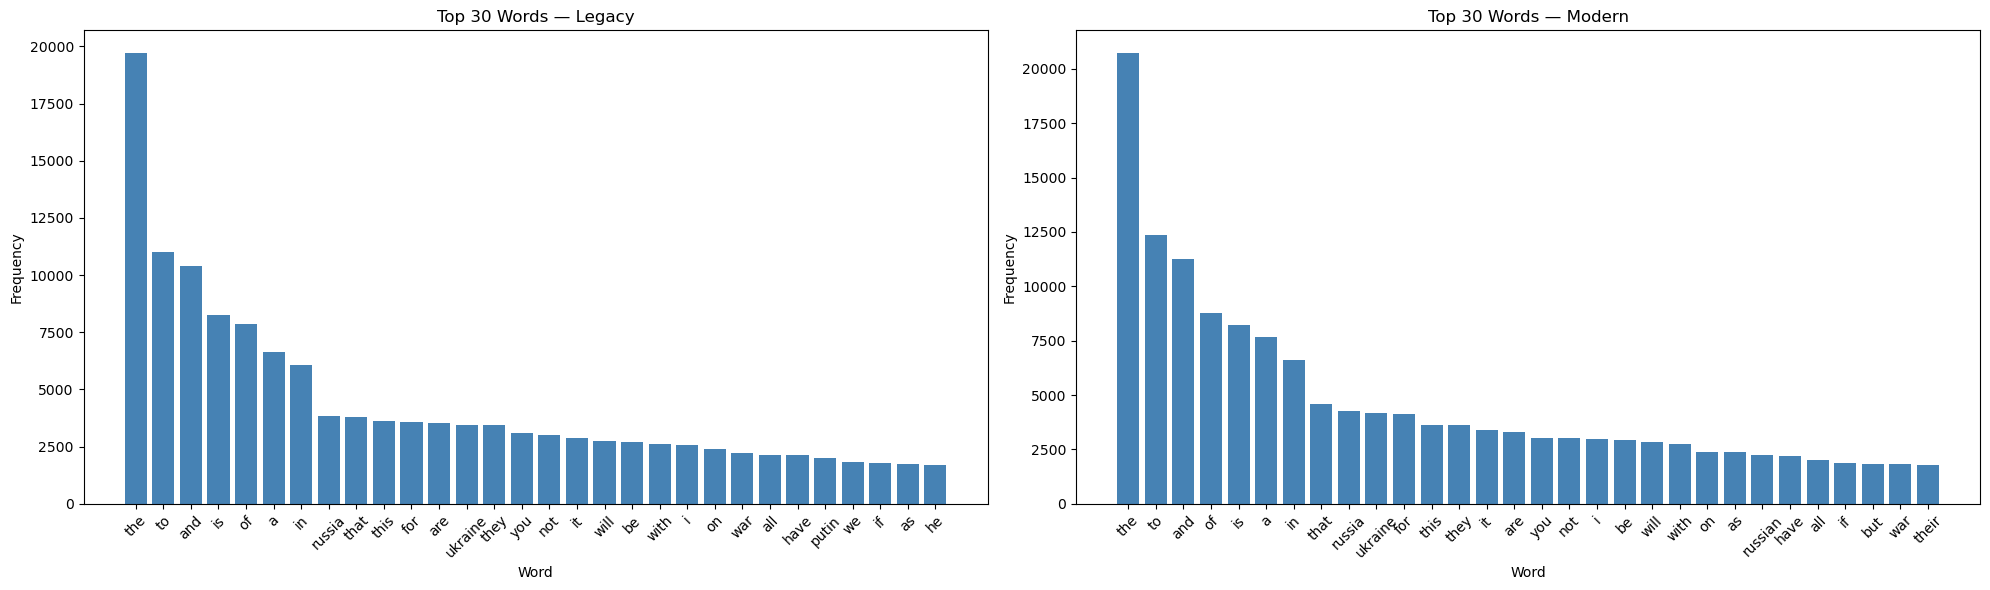

In [99]:
def plot_top_words(comments, label, ax, n=30):
    tokens = []
    for c in comments:
        tokens.extend(c["text"].split())
    top_n = Counter(tokens).most_common(n)
    words, counts = zip(*top_n)
    ax.bar(words, counts, color="steelblue")
    ax.set_title(f"Top {n} Words — {label}")
    ax.set_xlabel("Word")
    ax.set_ylabel("Frequency")
    ax.tick_params(axis="x", rotation=45)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6))
plot_top_words(legacy_comments,  "Legacy", ax1)
plot_top_words(modern_comments, "Modern", ax2)
plt.tight_layout()
plt.show()

# Preprocessing
Preprocessing steps below include:
- Conversion to lowercase
- URL removal
- Abbreviations and acronyms replaced with natural language words
- Digits and fractions removed
- Tokenization into individual words
- Non-alphabetic tokens (punctuation, symbols) removed
- Stop words removed

In [100]:
def _preprocess_text(text):
    text = re.sub(r"https?://\S+", "", text)          # strip URLs
    text = abbrev_pattern.sub(lambda m: ABBREVIATIONS[m.group(0)], text)
    text = re.sub(r"\b\d+([./]\d+)?\b", "", text)
    tokens = nltk.word_tokenize(text)
    tokens = [t.strip() for t in tokens if t.strip().isalpha()]
    tokens = [t for t in tokens if t not in stop_words]
    return tokens


def preprocess_comments(comments):
    """Tokenize and clean comments in-place; prints a summary."""
    for c in comments:
        c["tokens"] = _preprocess_text(c["text"])
        c["text"] = " ".join(c["tokens"])
    print(f"Preprocessed {len(comments)} comments")

preprocess_comments(legacy_comments)
preprocess_comments(modern_comments)

Preprocessed 14550 comments
Preprocessed 12509 comments


### Counting Top 50 Words After Preprocessing

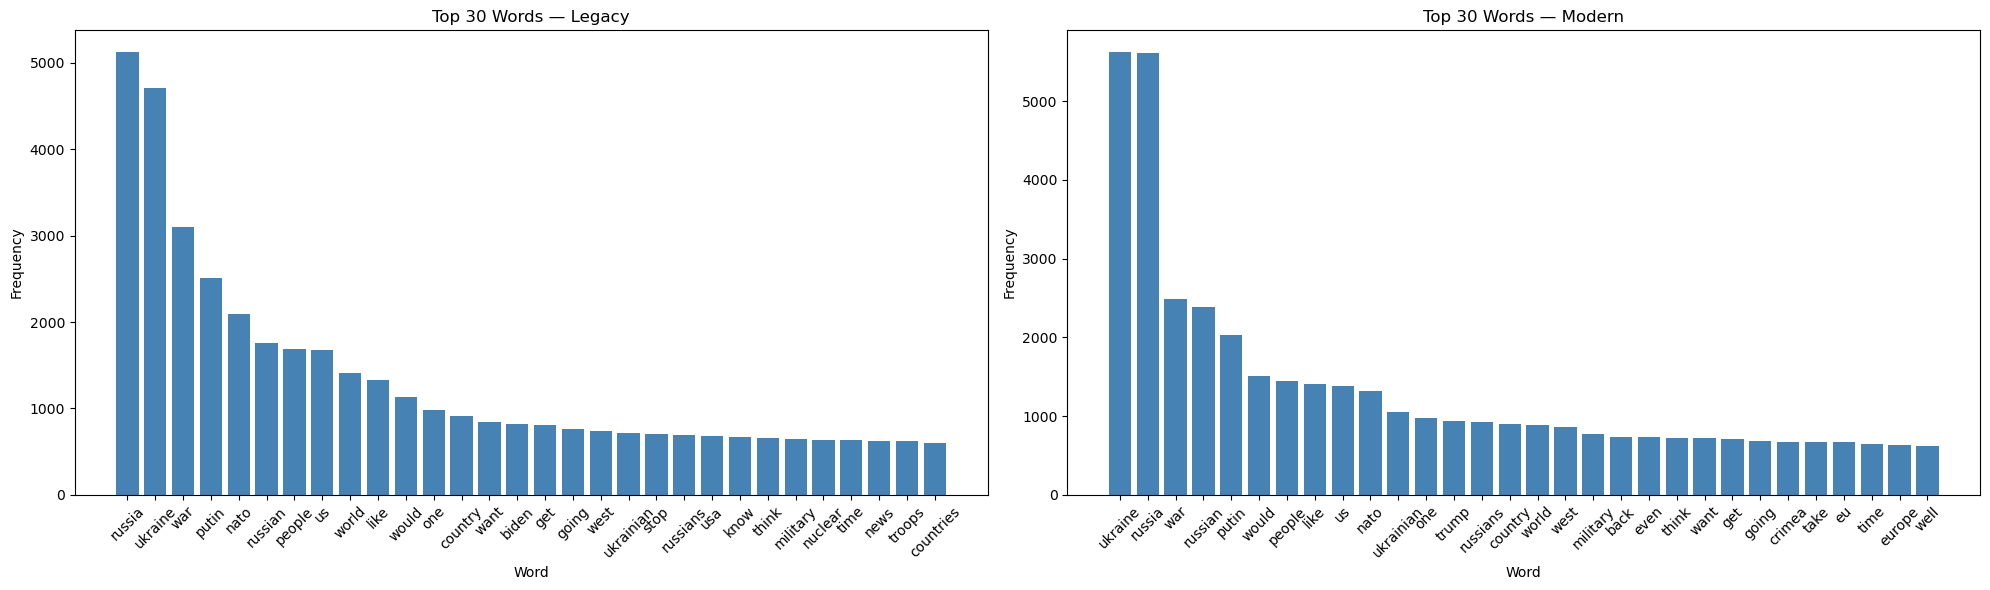

In [101]:
def plot_top_words(comments, label, ax, n=30):
    tokens = []
    for c in comments:
        tokens.extend(c["text"].split())
    top_n = Counter(tokens).most_common(n)
    words, counts = zip(*top_n)
    ax.bar(words, counts, color="steelblue")
    ax.set_title(f"Top {n} Words — {label}")
    ax.set_xlabel("Word")
    ax.set_ylabel("Frequency")
    ax.tick_params(axis="x", rotation=45)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6))
plot_top_words(legacy_comments,  "Legacy", ax1)
plot_top_words(modern_comments, "Modern", ax2)
plt.tight_layout()
plt.show()

# Sentiment Analysis

In [91]:
def run_sentiment(comments, pos_words, neg_words):
    """
    Run word-counting and VADER sentiment on preprocessed comments.
    Adds countSentiment, countLabel, vaderScores, vaderCompound, vaderLabel to each comment.
    Returns a summary dict.
    """
    sia = SentimentIntensityAnalyzer()
    count_labels = Counter()
    vader_labels = Counter()

    for c in comments:
        # Word counting
        pos = sum(1 for t in c["tokens"] if t in pos_words)
        neg = sum(1 for t in c["tokens"] if t in neg_words)
        score = pos - neg
        c["countSentiment"] = score
        c["countLabel"] = "positive" if score > 0 else ("negative" if score < 0 else "neutral")
        count_labels[c["countLabel"]] += 1

        # VADER (uses raw text for punctuation/caps)
        scores = sia.polarity_scores(c["raw_text"])
        c["vaderScores"] = scores
        c["vaderCompound"] = scores["compound"]
        if scores["compound"] >= 0.05:
            c["vaderLabel"] = "positive"
        elif scores["compound"] <= -0.05:
            c["vaderLabel"] = "negative"
        else:
            c["vaderLabel"] = "neutral"
        vader_labels[c["vaderLabel"]] += 1

    total = len(comments)
    return {
        "total": total,
        "count": {k: {"n": v, "pct": v / total * 100} for k, v in count_labels.items()},
        "vader": {k: {"n": v, "pct": v / total * 100} for k, v in vader_labels.items()},
        "vader_mean": sum(c["vaderCompound"] for c in comments) / total,
    }
    
pos_words, neg_words = load_words()
legacy_summary  = run_sentiment(legacy_comments,  pos_words, neg_words)
modern_summary  = run_sentiment(modern_comments,  pos_words, neg_words)


In [94]:
def compare_summaries(legacy_summary, modern_summary):
    """Print sentiment results for both datasets side by side."""
    cats = ("positive", "negative", "neutral")
    for method in ("count", "vader"):
        print(f"\n  [{method}]")
        print(f"  {'':12} {'Legacy':>18} {'Modern':>18}")
        for cat in cats:
            l = legacy_summary[method].get(cat, {"n": 0, "pct": 0.0})
            m = modern_summary[method].get(cat, {"n": 0, "pct": 0.0})
            print(f"  {cat:12} {l['n']:>6} ({l['pct']:5.1f}%)   {m['n']:>6} ({m['pct']:5.1f}%)")
    print(f"\n  {'vader mean':12} {legacy_summary['vader_mean']:>18.3f} {modern_summary['vader_mean']:>18.3f}")
    
compare_summaries(legacy_summary, modern_summary)


  [count]
                           Legacy             Modern
  positive       3351 ( 23.0%)     3656 ( 29.2%)
  negative       6013 ( 41.2%)     4655 ( 37.1%)
  neutral        5216 ( 35.8%)     4226 ( 33.7%)

  [vader]
                           Legacy             Modern
  positive       4421 ( 30.3%)     4385 ( 35.0%)
  negative       7313 ( 50.2%)     5625 ( 44.9%)
  neutral        2846 ( 19.5%)     2527 ( 20.2%)

  vader mean               -0.136             -0.080
